# Peak-Recovery Completeness Plots

This notebook reads the saved outputs from the Gaussian, ring, and overlapping-region completeness runs, combines them, and makes diagnostic plots for recovery as a function of luminosity, size, surface brightness, ionization, environment, and morphology.

Expected input folders by default:

- `peak_completeness/results_gaussian/`
- `peak_completeness/results_ring/`
- `peak_completeness/results_overlap_pair/`

Each folder should contain `all_injected_sources_recovery.csv` from `python -m peak_completeness.run_peak_completeness`.

In [12]:

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220
})

ROOT = Path.cwd()
if ROOT.name != "PAPER1":
    # Allows running from inside peak_completeness/ as well as repo root.
    ROOT = ROOT.parent

CANDIDATE_RESULT_DIRS = {
    "gaussian_pc_lum": ROOT / "peak_completeness" / "results_gaussian_pc_lum",
    "custom_pc_lum": ROOT / "peak_completeness" / "results_custom_pc_lum",
    "gaussian": ROOT / "peak_completeness" / "results_gaussian",
    "custom": ROOT / "peak_completeness" / "results_custom",
    "ring": ROOT / "peak_completeness" / "results_ring",
    "overlap_pair": ROOT / "peak_completeness" / "results_overlap",
}

# Pick the runs to compare here. Paths that do not exist are skipped below.
RESULT_SET_NAMES = ["gaussian_pc_lum", "custom_pc_lum", "gaussian", "custom"]
RESULT_DIRS = {
    name: CANDIDATE_RESULT_DIRS[name]
    for name in RESULT_SET_NAMES
    if (CANDIDATE_RESULT_DIRS[name] / "all_injected_sources_recovery.csv").exists()
}
print("Using result sets:")
for name, path in RESULT_DIRS.items():
    print(f" - {name}: {path}")

PLOT_DIR = ROOT / "peak_completeness" / "completeness_plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.linewidth": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

plt.rcParams["text.usetex"] = False

plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=20)

plt.rc('xtick', direction='in', top=True)
plt.rc('ytick', direction='in', right=True)
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True




Using result sets:
 - gaussian_pc_lum: /Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/peak_completeness/results_gaussian_pc_lum
 - gaussian: /Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/peak_completeness/results_gaussian
 - custom: /Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/peak_completeness/results_custom


In [22]:
# load in the catalog

catalog_method = 'summed_map'
catalog_dig_mode = 'dig_subtracted'
# Choose which extinction-corrected flux set downstream plots should use.
# Options: 'digsub_dered' or 'nodig_dered'.
CATALOG_FLUX_VERSION = 'digsub_dered'
field_catalog_pattern = f"flux_catalogs/{catalog_method}/{catalog_dig_mode}/flux_catalog_{{FIELD}}.csv"
primary_only = True
plot_root = Path('../PAPER_PLOTS') / catalog_method / catalog_dig_mode
plot_root.mkdir(parents=True, exist_ok=True)
PUBLISHED_CATALOG_PATH = plot_root / 'tables' / 'M33_emission_region_properties.csv'

cat = pd.read_csv(PUBLISHED_CATALOG_PATH)

In [23]:
def read_recovery_tables(result_dirs):
    frames = []
    missing = []
    for label, folder in result_dirs.items():
        path = folder / "all_injected_sources_recovery.csv"
        if not path.exists():
            missing.append(path)
            continue
        frame = pd.read_csv(path)
        if "morphology" not in frame:
            frame["morphology"] = label
        frame["result_set"] = label
        frames.append(frame)
    if missing:
        print("Missing result files:")
        for path in missing:
            print(" -", path)
    if not frames:
        raise FileNotFoundError("No all_injected_sources_recovery.csv files were found. Run the terminal tests first.")
    return pd.concat(frames, ignore_index=True)


df = read_recovery_tables(RESULT_DIRS)
df["recovered"] = df["recovered"].astype(bool)

for col in [
    "injected_radius_px", "sigma_px", "log_L_Ha_sum", "L_Ha_sum",
    "surface_brightness_ha", "total_peak_amp", "log_oiii_ha", "log_ha_oiii",
    "local_amp_background", "local_threshold", "nearest_existing_peak_distance_px",
    "match_distance_px", "n_detected_peaks_in_region",
]:
    if col in df:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["recovery_label"] = np.where(df["recovered"], "Recovered", "Missed")
df["log_surface_brightness_ha"] = np.log10(df["surface_brightness_ha"].where(df["surface_brightness_ha"] > 0))
df["log_total_peak_amp"] = np.log10(df["total_peak_amp"].where(df["total_peak_amp"] > 0))

print(f"Loaded {len(df):,} injected sources")
display(df.groupby(["morphology", "field"])["recovered"].agg(n_injected="size", n_recovered="sum", recovery_fraction="mean"))

Loaded 260,000 injected sources


n_injected  n_recovered  recovery_fraction
morphology field                                            
custom     F5          10000         7217            0.72170
           F6          10000         2835            0.28350
           F7          10000         8150            0.81500
           F8          10000         8160            0.81600
           F9          10000         8439            0.84390
           NE          10000         8773            0.87730
           NW          10000         8856            0.88560
           SE          10000         8582            0.85820
           SW          10000         9104            0.91040
gaussian   F5          20000        14265            0.71325
           F6          10000         3392            0.33920
           F7          20000        15190            0.75950
           F8          20000        15245            0.76225
           F9          20000        15443            0.77215
           NE          20000        16134            0.80670
           NW          20000        16196            0.80980
           SE          20000        15709            0.78545
           SW          20000        16480            0.82400

In [24]:
per_field = df.groupby(["morphology", "field"])["recovered"].agg(n_injected="size", n_recovered="sum", recovery_fraction="mean")

In [25]:
len(per_field)

18

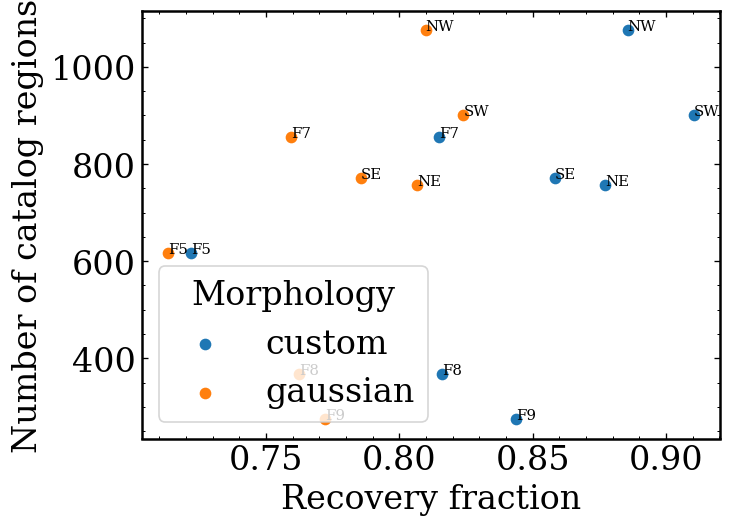

In [26]:
# Plot total number of catalog regions per field versus recovery fraction.
# per_field has one row per morphology+field, while n_field has one row per field,
# so merge by field before plotting.

n_field = cat.groupby("Field").size().reset_index(name="n_regions")
fields = ["F5", "F7", "F8", "F9", "NE", "NW", "SE", "SW"]
n_field = n_field[n_field["Field"].isin(fields)].copy()

plot_df = per_field.reset_index().merge(
    n_field,
    left_on="field",
    right_on="Field",
    how="inner",
)
plot_df["field_order"] = pd.Categorical(plot_df["field"], categories=fields, ordered=True)
plot_df = plot_df.sort_values(["morphology", "field_order"])

fig, ax = plt.subplots(figsize=(6.5, 4.8))
for morphology, group in plot_df.groupby("morphology", sort=False):
    ax.scatter(group["recovery_fraction"], group["n_regions"], label=morphology)
    for _, row in group.iterrows():
        ax.text(row["recovery_fraction"], row["n_regions"], row["field"], fontsize=9)

ax.set_xlabel("Recovery fraction")
ax.set_ylabel("Number of catalog regions")
ax.legend(title="Morphology")
fig.tight_layout()
fig.savefig(PLOT_DIR / "field_region_count_vs_recovery_fraction.png")
plt.show()


## Overall Recovery And Segmentation Summary

,morphology,n_injected,n_recovered,recovery_fraction,mean_detected_peaks_per_region,median_detected_peaks_per_region,multiple_peak_fraction,median_match_distance_px,recovery_percent
0,custom,90000,70116,0.779067,1.389322,1.0,0.213444,1.0,77.906667
1,gaussian,170000,128054,0.753259,1.039529,1.0,0.142871,1.0,75.325882


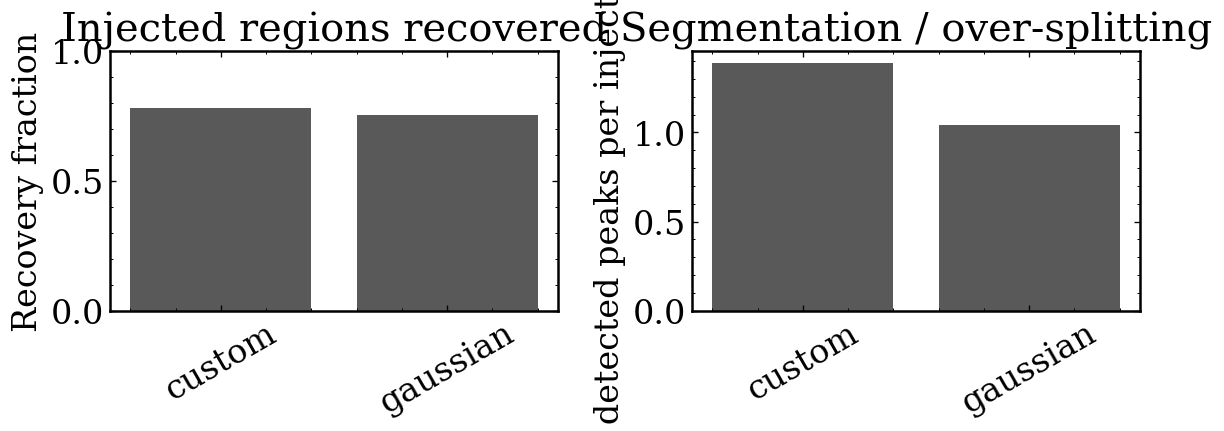

In [27]:
summary = (
    df.groupby("morphology")
    .agg(
        n_injected=("recovered", "size"),
        n_recovered=("recovered", "sum"),
        recovery_fraction=("recovered", "mean"),
        mean_detected_peaks_per_region=("n_detected_peaks_in_region", "mean"),
        median_detected_peaks_per_region=("n_detected_peaks_in_region", "median"),
        multiple_peak_fraction=("multiple_peaks_detected", "mean"),
        median_match_distance_px=("match_distance_px", "median"),
    )
    .reset_index()
)
summary["recovery_percent"] = 100 * summary["recovery_fraction"]
summary.to_csv(PLOT_DIR / "notebook_morphology_summary.csv", index=False)
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(summary["morphology"], summary["recovery_fraction"], color="0.35")
axes[0].set_ylabel("Recovery fraction")
axes[0].set_ylim(0, 1)
axes[0].set_title("Injected regions recovered")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(summary["morphology"], summary["mean_detected_peaks_per_region"], color="0.35")
axes[1].set_ylabel("Mean detected peaks per injected region")
axes[1].set_title("Segmentation / over-splitting")
axes[1].tick_params(axis="x", rotation=30)

fig.tight_layout()
fig.savefig(PLOT_DIR / "morphology_recovery_and_segmentation.png")
plt.show()

In [28]:
for col in cat.columns:
    print(col)

ID
Field
RA_deg
Dec_deg
N_spaxels
R_c_pc
R_16_pc
R_50_pc
R_84_pc
Halpha_flux_raw
Halpha_flux_dered
Halpha_flux_bgsub
Halpha_flux_err
Halpha_SNR
Hbeta_flux_raw
Hbeta_flux_dered
Hbeta_flux_bgsub
Hbeta_flux_err
Hbeta_SNR
[OIII]5007_flux_raw
[OIII]5007_flux_dered
[OIII]5007_flux_bgsub
[OIII]5007_flux_err
[OIII]5007_SNR
[NII]6583_flux_raw
[NII]6583_flux_dered
[NII]6583_flux_bgsub
[NII]6583_flux_err
[NII]6583_SNR
[SII]6716_flux_raw
[SII]6716_flux_dered
[SII]6716_flux_bgsub
[SII]6716_flux_err
[SII]6716_SNR
[SII]6731_flux_raw
[SII]6731_flux_dered
[SII]6731_flux_bgsub
[SII]6731_flux_err
[SII]6731_SNR
[OII]3727_flux_raw
[OII]3727_flux_dered
[OII]3727_flux_bgsub
[OII]3727_flux_err
[OII]3727_SNR
A_V_mag
E_BV_mag
BPT_class
L_Halpha_raw
L_Halpha_dered
L_Halpha_bgsub
has_WR
has_SNR
has_PN
primary
v_helio_mean_kms
v_helio_mean_err_kms
sigma_mean_kms
sigma_mean_err_kms
n_kinematic_spaxels
ne
ne_err_minus
ne_err_plus
Pthermal
Pthermal_err_minus
Pthermal_err_plus
logU_KK04
logU_KK04_err
Z_N2_Brazzini2024

## Completeness Figure

These panels show whether recovery is driven more strongly by luminosity, size, or surface brightness. The second panel is usually the clearest diagnostic because the peak finder operates on local contrast and threshold excess.

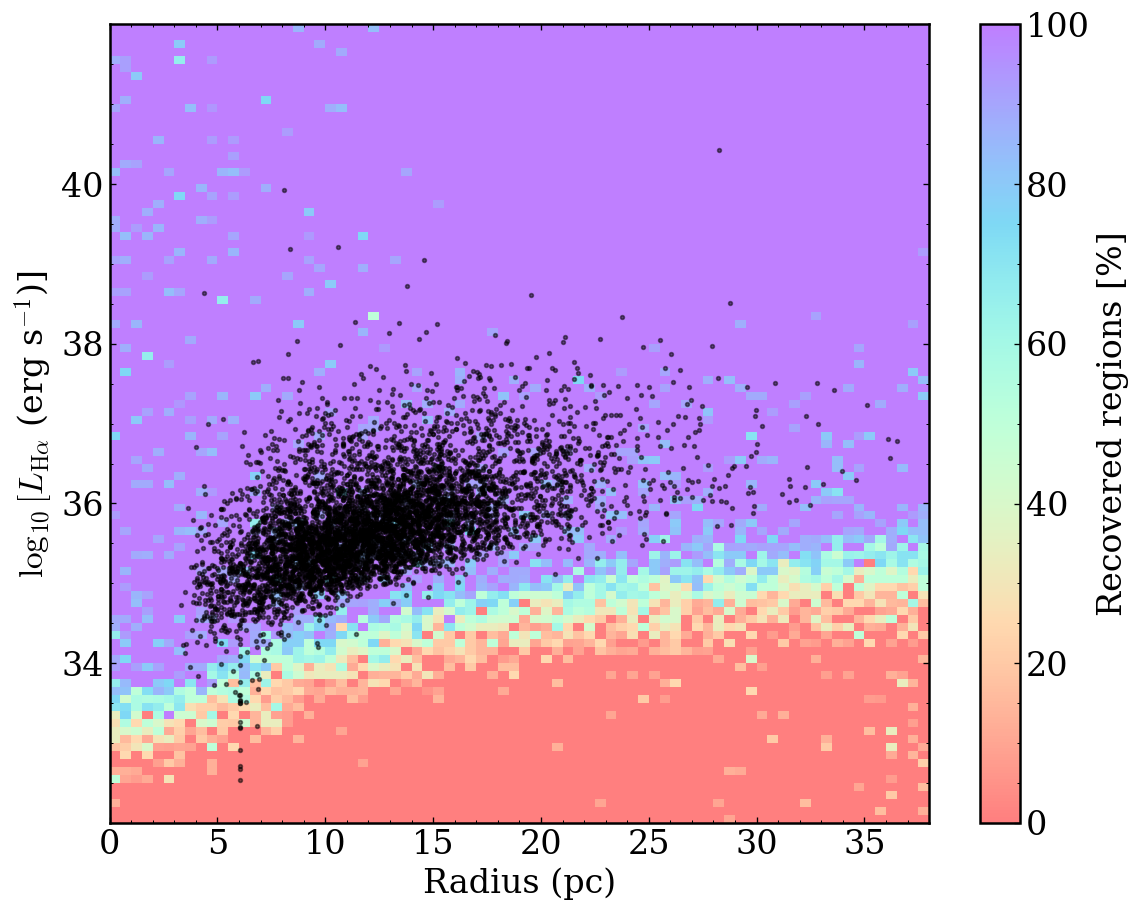

ValueError: No finite radius/luminosity values available for the recovery map.

In [29]:
def plot_recovery_percent_density(
    data,
    label="all",
    x="injected_radius_pc",
    y="log_L_Ha_sum",
    x_bins=100,
    y_bins=100,
    min_count=1,
):
    work = data[[x, y, "recovered"]].dropna().copy()
    work = work[np.isfinite(work[x]) & np.isfinite(work[y])]
    if work.empty:
        raise ValueError("No finite radius/luminosity values available for the recovery map.")

    x_edges = np.linspace(work[x].min(), work[x].max(), x_bins + 1)
    y_edges = np.linspace(work[y].min(), work[y].max(), y_bins + 1)

    total_counts, _, _ = np.histogram2d(work[x], work[y], bins=[x_edges, y_edges])
    recovered_counts, _, _ = np.histogram2d(
        work.loc[work["recovered"], x],
        work.loc[work["recovered"], y],
        bins=[x_edges, y_edges],
    )

    recovery_percent = np.full_like(total_counts, np.nan, dtype=float)
    valid = total_counts >= min_count
    recovery_percent[valid] = 100 * recovered_counts[valid] / total_counts[valid]

    fig, ax = plt.subplots(figsize=(10, 8))
    
    #also smooth the recovery percent map with a gaussian filter
    #import gaussian_filter from scipy.ndimage
    from scipy.ndimage import gaussian_filter
    
    #ignore nans in filter
    recovery_percent = np.nan_to_num(recovery_percent, nan=0)
    # recovery_percent = gaussian_filter(recovery_percent, sigma=1)

    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        recovery_percent.T,
        cmap="rainbow_r",
        vmin=0,
        vmax=100,
        shading="auto",
        alpha=0.5
    )
    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label("Recovered regions [%]")

    ax.set_xlabel("Radius (pc)")
    ax.set_ylabel(r"$\log_{10} [L_{\mathrm{H}\alpha}$ (erg s$^{-1}$)]")
    plt.scatter(cat[R"R_c_pc"], np.log10(cat[f"L_Halpha_bgsub"]), s=5, c="k", alpha=0.5, label="Catalog regions")
    # plt.scatter(cat[R"R_c_pc"], np.log10(cat[f"L_Halpha_dered"]), s=5, c="r", alpha=0.5, label="Catalog regions")
    plt.xlim(0,38)
    # ax.legend()
    fig.tight_layout()
    safe_label = str(label).replace("/", "_").replace(" ", "_")
    fig.savefig(PLOT_DIR / f"recovered_missed_luminosity_vs_size_{safe_label}.png")
    return fig, ax, recovery_percent, total_counts, x_edges, y_edges


# Make one L-vs-R completeness map per result_set+morphology.
# Do not combine gaussian_pc_lum and gaussian into one map: they sample different
# radius/luminosity ranges and produce a smaller rectangle inside the larger map.
preferred_pairs = [
    ("gaussian_pc_lum", "gaussian"),
    ("custom_pc_lum", "custom"),
    ("gaussian", "gaussian"),
    ("custom", "custom"),
]
available_pairs = set(df[["result_set", "morphology"]].drop_duplicates().itertuples(index=False, name=None))
density_plot_pairs = [pair for pair in preferred_pairs if pair in available_pairs]
if not density_plot_pairs:
    density_plot_pairs = sorted(available_pairs)[:4]

all_recovery_map_rows = []
for result_set, morphology in density_plot_pairs:
    sub = df[(df["result_set"] == result_set) & (df["morphology"] == morphology)]
    label = f"{result_set}_{morphology}"
    fig, ax, recovery_percent, total_counts, radius_edges, luminosity_edges = plot_recovery_percent_density(
        sub,
        label=label,
        x="injected_radius_pc",
        x_bins=100,
        y_bins=100,
    )
    # ax.set_title(f"{result_set}: {morphology} recovery")
    plt.show()

    for i in range(len(radius_edges) - 1):
        for j in range(len(luminosity_edges) - 1):
            if total_counts[i, j] == 0:
                continue
            all_recovery_map_rows.append({
                "result_set": result_set,
                "morphology": morphology,
                "radius_min_pc": radius_edges[i],
                "radius_max_pc": radius_edges[i + 1],
                "log_L_Ha_min": luminosity_edges[j],
                "log_L_Ha_max": luminosity_edges[j + 1],
                "n_injected": int(total_counts[i, j]),
                "recovery_percent": recovery_percent[i, j],
            })

pd.DataFrame(all_recovery_map_rows).to_csv(
    PLOT_DIR / "notebook_recovery_percent_luminosity_vs_size_bins.csv",
    index=False,
)


In [ ]:
from scipy.ndimage import gaussian_filter
gaussian_filter?

In [ ]:
sub.columns

## Binned Recovery Fractions

These plots are useful for quoting completeness limits and showing trends with luminosity, surface brightness, ionization, size, and local environment.

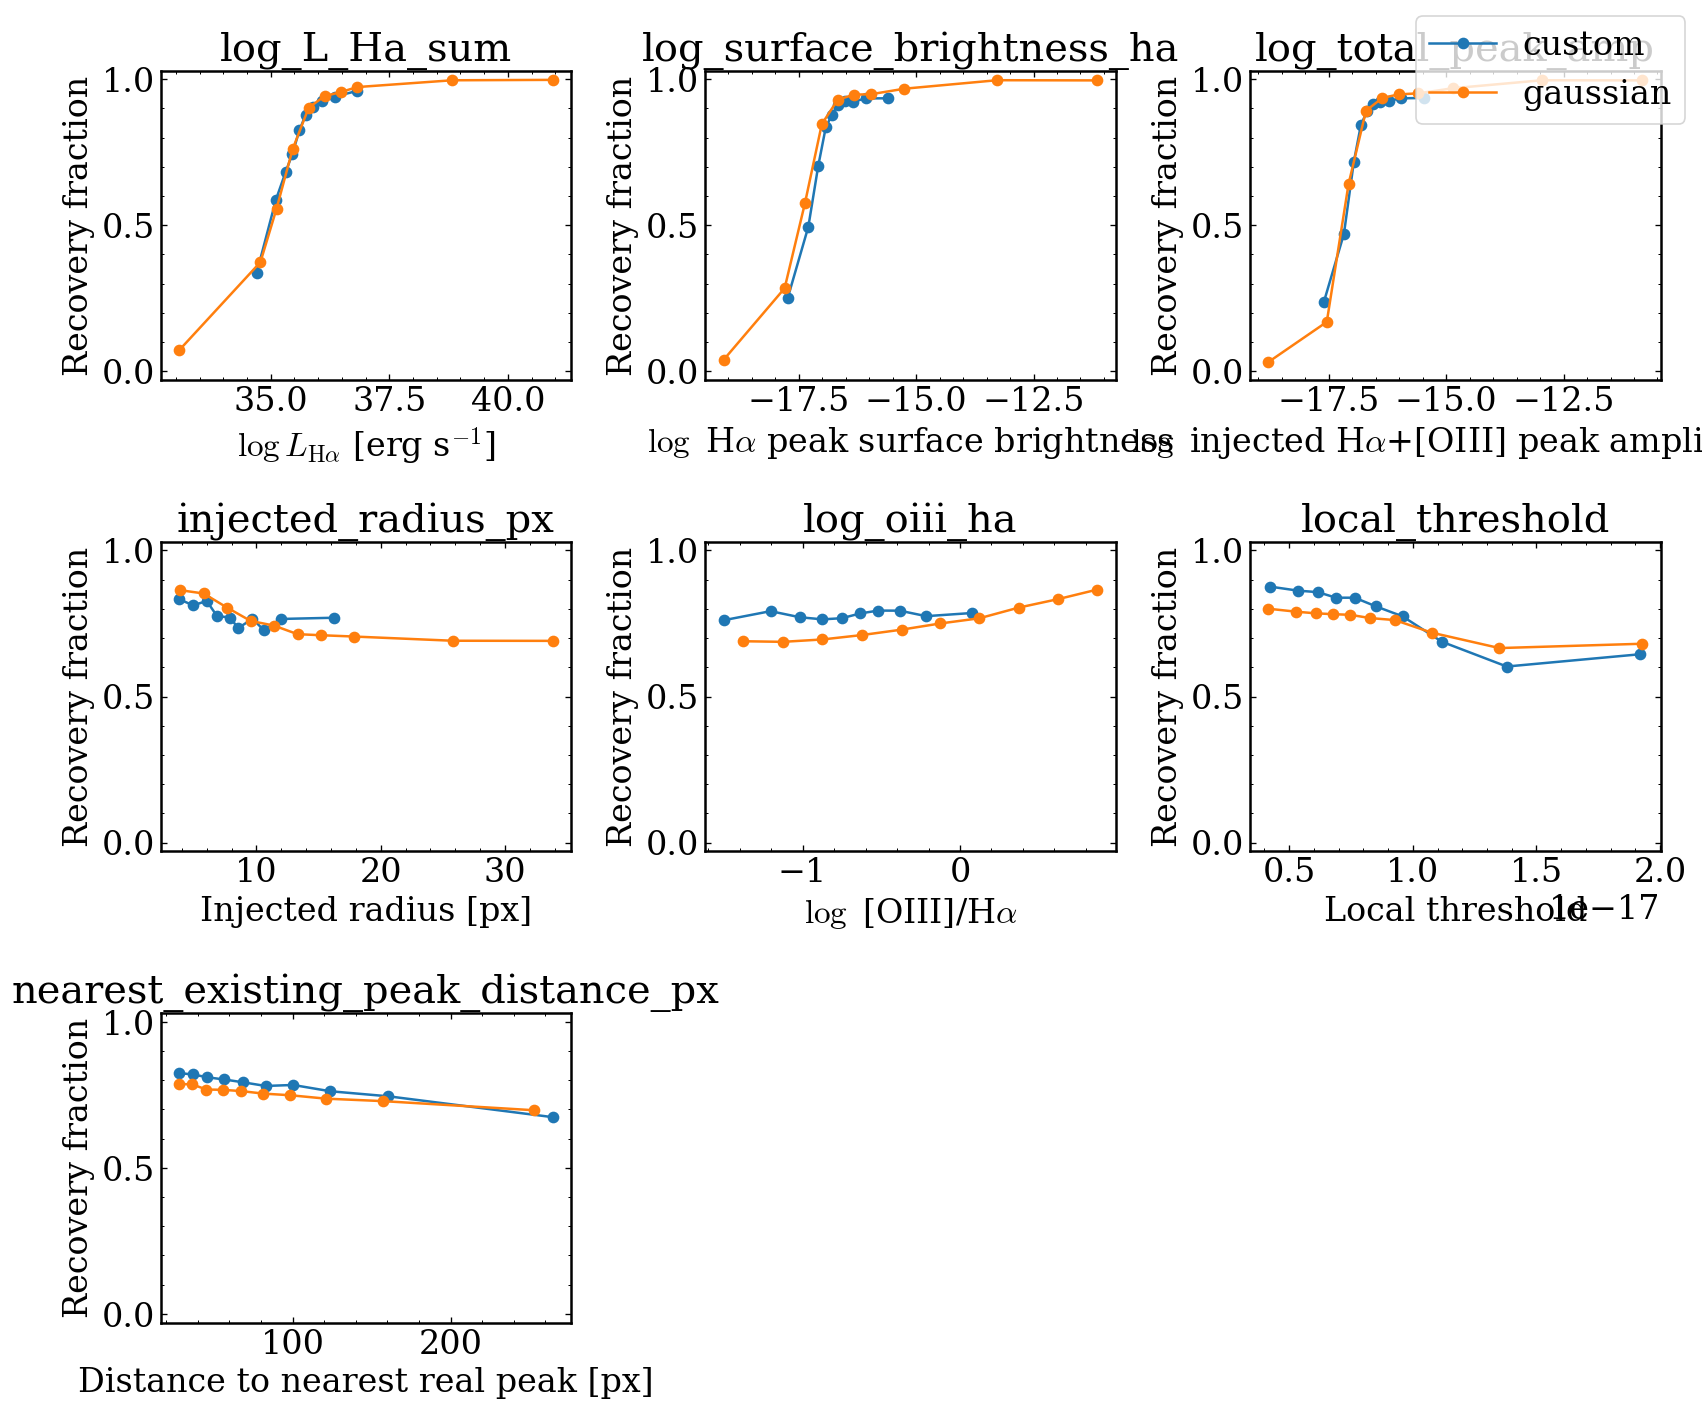

In [ ]:
def binned_recovery(data, column, n_bins=10):
    work = data[[column, "recovered", "morphology"]].dropna().copy()
    if work[column].nunique() < 2:
        return pd.DataFrame()
    pieces = []
    for morphology, group in work.groupby("morphology"):
        if group[column].nunique() < 2:
            continue
        group = group.copy()
        group["bin"] = pd.qcut(group[column], q=min(n_bins, group[column].nunique()), duplicates="drop")
        out = (
            group.groupby("bin", observed=False)
            .agg(
                x=(column, "median"),
                n=("recovered", "size"),
                recovery_fraction=("recovered", "mean"),
            )
            .reset_index(drop=True)
        )
        out["morphology"] = morphology
        out["property"] = column
        pieces.append(out)
    return pd.concat(pieces, ignore_index=True) if pieces else pd.DataFrame()


properties = [
    ("log_L_Ha_sum", r"$\log L_{\mathrm{H}\alpha}$ [erg s$^{-1}$]"),
    ("log_surface_brightness_ha", r"$\log$ H$\alpha$ peak surface brightness"),
    ("log_total_peak_amp", r"$\log$ injected H$\alpha$+[OIII] peak amplitude"),
    ("injected_radius_px", "Injected radius [px]"),
    ("log_oiii_ha", r"$\log$ [OIII]/H$\alpha$"),
    ("local_threshold", "Local threshold"),
    ("nearest_existing_peak_distance_px", "Distance to nearest real peak [px]"),
]

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.ravel()
all_bins = []

for ax, (column, xlabel) in zip(axes, properties):
    binned = binned_recovery(df, column)
    if binned.empty:
        ax.set_axis_off()
        continue
    all_bins.append(binned)
    for morphology, group in binned.groupby("morphology"):
        ax.plot(group["x"], group["recovery_fraction"], marker="o", label=morphology)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Recovery fraction")
    ax.set_ylim(-0.03, 1.03)
    ax.set_title(column)

for ax in axes[len(properties):]:
    ax.set_axis_off()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.tight_layout()
fig.savefig(PLOT_DIR / "binned_recovery_fraction_by_property.png")
plt.show()

if all_bins:
    pd.concat(all_bins, ignore_index=True).to_csv(PLOT_DIR / "notebook_binned_recovery_fractions.csv", index=False)

## Halpha Luminosity Completeness Limit

This estimates the first binned Halpha luminosity where the recovery fraction exceeds 50%, 80%, and 90%. Use this as a descriptive completeness limit, not a sharp physical boundary.

In [ ]:
def completeness_limits(data, column="log_L_Ha_sum", levels=(0.5, 0.8, 0.9), n_bins=12):
    rows = []
    for morphology, group in data.dropna(subset=[column]).groupby("morphology"):
        if group[column].nunique() < 2:
            continue
        binned = binned_recovery(group, column, n_bins=n_bins)
        binned = binned[binned["morphology"] == morphology].sort_values("x")
        for level in levels:
            ok = binned[binned["recovery_fraction"] >= level]
            limit = ok["x"].iloc[0] if len(ok) else np.nan
            rows.append({
                "morphology": morphology,
                "completeness_level": level,
                "log_L_Ha_limit": limit,
                "L_Ha_limit": 10**limit if np.isfinite(limit) else np.nan,
            })
    return pd.DataFrame(rows)


limits = completeness_limits(df)
limits.to_csv(PLOT_DIR / "notebook_halpha_luminosity_completeness_limits.csv", index=False)
display(limits)

,morphology,completeness_level,log_L_Ha_limit,L_Ha_limit
0,custom,0.5,35.041779,1.100980e+35
1,custom,0.8,35.613158,4.103529e+35
2,custom,0.9,35.849530,7.071804e+35
3,gaussian,0.5,35.266497,1.847130e+35
4,gaussian,0.8,35.547115,3.524639e+35
5,gaussian,0.9,35.830286,6.765276e+35


## Peak Offset And Over-Segmentation

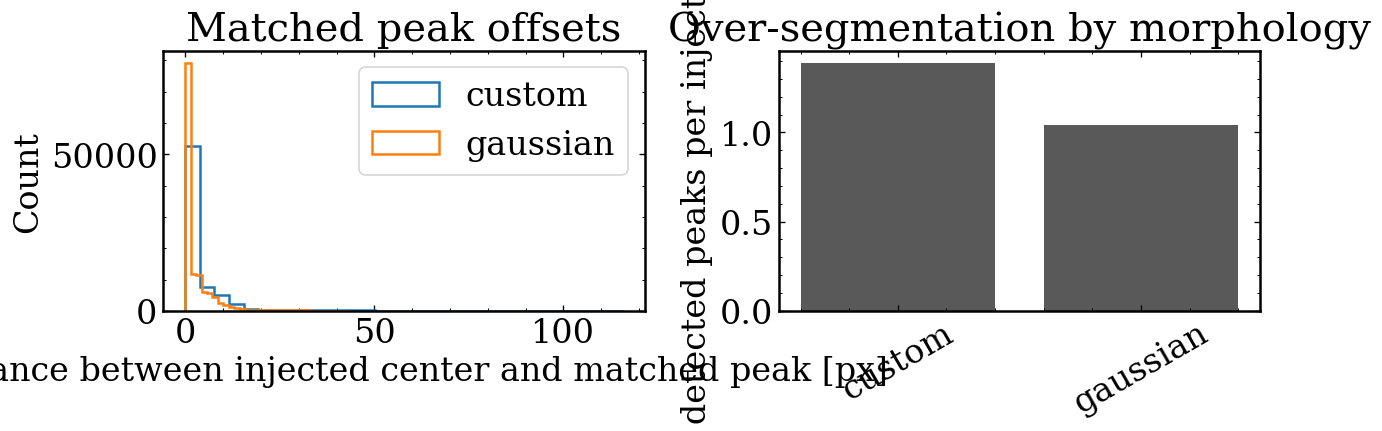

,morphology,n,median,mean,p84,p95
0,custom,70116,1.0,3.715105,7.000000,13.892444
1,gaussian,128054,1.0,2.588251,5.385165,10.440307


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for morphology, group in df[df["recovered"]].groupby("morphology"):
    axes[0].hist(group["match_distance_px"].dropna(), bins=30, histtype="step", linewidth=1.5, label=morphology)
axes[0].set_xlabel("Distance between injected center and matched peak [px]")
axes[0].set_ylabel("Count")
axes[0].set_title("Matched peak offsets")
axes[0].legend()

seg = (
    df.groupby("morphology")["n_detected_peaks_in_region"]
    .agg(mean="mean", median="median")
    .reset_index()
)
axes[1].bar(seg["morphology"], seg["mean"], color="0.35")
axes[1].set_ylabel("Mean detected peaks per injected region")
axes[1].set_title("Over-segmentation by morphology")
axes[1].tick_params(axis="x", rotation=30)

fig.tight_layout()
fig.savefig(PLOT_DIR / "peak_offsets_and_segmentation.png")
plt.show()

offset_summary = (
    df[df["recovered"]]
    .groupby("morphology")["match_distance_px"]
    .agg(n="size", median="median", mean="mean", p84=lambda x: np.nanpercentile(x, 84), p95=lambda x: np.nanpercentile(x, 95))
    .reset_index()
)
offset_summary.to_csv(PLOT_DIR / "notebook_peak_offset_summary.csv", index=False)
display(offset_summary)

## Saved Outputs

The notebook writes figures and compact tables to `peak_completeness/completeness_plots/`.